# Minimum Variance and de Hoffmann-Teller Analysis

author: Louis Richard\
Single-spacecraft analysis of a current sheet: boundary normal from minimum
variance analysis (MVA) of the magnetic field, and velocity of the
de Hoffmann-Teller (HT) frame from the electric and magnetic fields. Uses a
synthetic rotational discontinuity with known normal and frame velocity, so
the estimates can be checked. See
[Sonnerup and Scheible (1998)](https://www.issibern.ch/forads/sr-001-08.pdf)
and [Khrabrov and Sonnerup (1998)](https://www.issibern.ch/forads/sr-001-09.pdf)
for the methods.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from pyrfu import pyrf
from pyrfu.plot import plot_line, use_pyrfu_style

use_pyrfu_style(usetex=False)

## Synthetic current sheet
### Boundary frame
The current sheet has normal $\hat{\mathbf{n}}$, and $\hat{\mathbf{l}}$,
$\hat{\mathbf{m}}$ in the plane of the sheet, defined in an arbitrary
(e.g., GSE) frame.

In [2]:
n_true = np.array([0.8, 0.3, 0.5])
n_true /= np.linalg.norm(n_true)
l_true = np.cross([0.0, 1.0, 0.0], n_true)
l_true /= np.linalg.norm(l_true)
m_true = np.cross(n_true, l_true)

lmn_true = np.transpose([l_true, m_true, n_true])
lmn_true

array([[ 0.52999894, -0.25698229,  0.80812204],
       [ 0.        ,  0.952976  ,  0.30304576],
       [-0.8479983 , -0.16061393,  0.50507627]])

### Magnetic and electric fields
In the HT frame the structure is stationary and the electric field vanishes.
In the spacecraft frame, where the structure moves at $\mathbf{V}_{HT}$, the
electric field is $\mathbf{E} = -\mathbf{V}_{HT}\times\mathbf{B}$. The field
rotates in the $(\hat{\mathbf{l}}, \hat{\mathbf{m}})$ plane with a constant
normal component $B_n$, as a rotational discontinuity, and the spacecraft
crosses the sheet of half-thickness $\delta$ in $\delta / |V_n|$.

64 Hz magnetic field and 128 Hz electric field, with Gaussian noise.

In [3]:
tint = ["2019-09-14T07:54:00.000", "2019-09-14T07:54:40.000"]
t_start = pyrf.iso86012datetime64(np.array(tint))[0]


def time_line(f_s, duration=40.0):
    n_t = int(duration * f_s)
    return t_start + (np.arange(n_t) / f_s * 1e9).astype("timedelta64[ns]")


v_ht_true = np.array([-250.0, 100.0, 50.0])  # [km/s]
v_n = np.dot(v_ht_true, n_true)
b_lobe, b_guide, b_n, delta = 20.0, 8.0, 2.0, 300.0  # [nT], [km]


def current_sheet(time):
    t_sec = (time - t_start).astype(np.int64) * 1e-9
    s_n = -v_n * (t_sec - 20.0)
    b_lmn = np.transpose(
        [
            b_lobe * np.tanh(s_n / delta),
            b_guide + 10.0 / np.cosh(s_n / delta),
            np.full(len(time), b_n),
        ],
    )
    return b_lmn @ lmn_true.T


rng = np.random.default_rng(0)

time_b, time_e = time_line(64.0), time_line(128.0)
b_data = current_sheet(time_b) + 0.5 * rng.standard_normal((len(time_b), 3))
b_xyz = pyrf.ts_vec_xyz(time_b, b_data, {"UNITS": "nT"})

e_data = -1e-3 * np.cross(v_ht_true, current_sheet(time_e))
e_data += 0.5 * rng.standard_normal((len(time_e), 3))
e_xyz = pyrf.ts_vec_xyz(time_e, e_data, {"UNITS": "mV/m"})

print(f"V_n = {v_n:.1f} km/s, crossing time ~ {2 * delta / abs(v_n):.1f} s")

V_n = -146.5 km/s, crossing time ~ 4.1 s


## Minimum variance analysis
### Boundary normal
`mva` returns the field in the minimum variance frame, the eigenvalues
$\lambda_1 > \lambda_2 > \lambda_3$ of the magnetic variance matrix and the
eigenvectors (as columns). The normal is the minimum variance direction. MVA
should be applied to an interval including the whole current sheet, but not
much of the surrounding regions where the fluctuations are unrelated to the
boundary.

In [4]:
tint_mva = ["2019-09-14T07:54:16.000", "2019-09-14T07:54:24.000"]
b_mva = pyrf.time_clip(b_xyz, tint_mva)

b_lmn, lamb, lmn = pyrf.mva(b_mva)

print("eigenvalues   :", lamb.round(2))
print("l2 / l3       :", f"{lamb[1] / lamb[2]:.1f}")

eigenvalues   : [204.06   6.     0.27]
l2 / l3       : 22.0


The eigenvectors are defined up to a sign. A convention is chosen afterwards,
e.g., the normal pointing outward of the magnetosphere for the magnetopause.
Here the normal is oriented along $+x$, and $\hat{\mathbf{m}}$ is flipped
with it to keep a right-handed frame.

In [5]:
if lmn[0, 2] < 0:
    lmn[:, 1:] *= -1

n_mva = lmn[:, 2]
print("N (MVA)       :", n_mva.round(3))
print("N (true)      :", n_true.round(3))
print(f"angle         : {np.rad2deg(np.arccos(np.dot(n_mva, n_true))):.2f} deg")

N (MVA)       : [0.807 0.307 0.504]
N (true)      : [0.808 0.303 0.505]
angle         : 0.21 deg


### Statistical error
For $M$ samples, the statistical uncertainty of the normal towards the
intermediate direction is
$\Delta\varphi_{32} = \sqrt{\lambda_3 \lambda_2 / ((M - 1)(\lambda_2 - \lambda_3)^2)}$
rad. It only accounts for the noise: a well separated $\lambda_2/\lambda_3$
(larger than 10, say) is needed for the normal to be well defined.

In [6]:
n_samples = len(b_mva)
dphi_32 = np.sqrt(lamb[2] * lamb[1] / ((n_samples - 1) * (lamb[1] - lamb[2]) ** 2))
print(f"error         : {np.rad2deg(dphi_32):.2f} deg")

error         : 0.57 deg


### Transform to the boundary frame
`new_xyz` rotates any vector time series into the new frame, given the
matrix of the unit vectors as columns. The normal component of the magnetic
field identifies a rotational discontinuity ($B_n \neq 0$).

In [7]:
b_lmn = pyrf.new_xyz(b_xyz, lmn, "lmn")
e_lmn = pyrf.new_xyz(e_xyz, lmn, "lmn")

print(f"<B_n> = {pyrf.time_clip(b_lmn, tint_mva)[:, 2].mean().data:.2f} nT")

<B_n> = 2.09 nT


### Constrained MVA
For a tangential discontinuity ($B_n = 0$) the `"<bn>=0"` constraint
imposes a vanishing average normal field. Applied to this rotational
discontinuity, it gives a biased normal, so the constraint is only to be used
when $B_n = 0$ is known to hold.

In [8]:
_, _, lmn_td = pyrf.mva(b_mva, "<bn>=0")
n_td = lmn_td[:, 2] * np.sign(lmn_td[0, 2])
print(f"angle         : {np.rad2deg(np.arccos(np.dot(n_td, n_true))):.2f} deg")

angle         : 7.95 deg


## de Hoffmann-Teller analysis
### Frame velocity
`vht` finds the frame velocity that minimizes the residual electric field
$\langle|\mathbf{E} + \mathbf{V}_{HT}\times\mathbf{B}|^2\rangle$. The
magnetic field is resampled to the electric field sampling. Only the
velocity perpendicular to the magnetic field is constrained, so the field
direction must vary over the interval (here, the rotation across the sheet).

In [9]:
e_ht_int = pyrf.time_clip(e_xyz, tint_mva)
v_ht, e_ht, dv_ht = pyrf.vht(e_ht_int, b_xyz)

print("V_HT          :", v_ht.round(1), "km/s")
print("dV_HT         :", dv_ht.round(1), "km/s")
print("V_HT (true)   :", v_ht_true, "km/s")

[05-Oct-26 16:28:03] INFO: v_ht =272.9905 * [-0.91473259  0.35762133  0.18807254] km/s
[05-Oct-26 16:28:03] INFO: slope = 0.9980, offs = 0.0094, cc = 0.9748
[05-Oct-26 16:28:03] INFO: dv_ht = 2.0747 * [0.50580165 0.64120475 0.57707985] km/s


V_HT          : [-249.7   97.6   51.3] km/s
dV_HT         : [1.  1.3 1.2] km/s
V_HT (true)   : [-250.  100.   50.] km/s


### Quality of the HT frame
The HT frame is well defined when $\mathbf{E}$ and
$\mathbf{E}_{HT} = -\mathbf{V}_{HT}\times\mathbf{B}$ are well correlated,
with a regression slope close to 1.

In [10]:
e_ht_obs = pyrf.time_clip(e_xyz, tint_mva)
slope, offset = np.polyfit(e_ht.data.ravel(), e_ht_obs.data.ravel(), 1)
corr_coeff = np.corrcoef(e_ht.data.ravel(), e_ht_obs.data.ravel())[0, 1]

print(f"slope = {slope:.3f}, offset = {offset:.3f} mV/m, cc = {corr_coeff:.3f}")

slope = 0.998, offset = 0.009 mV/m, cc = 0.975


### Convection electric field and drift velocity
`e_vxb` computes the convection electric field $-\mathbf{V}\times\mathbf{B}$
for a velocity time series, e.g., the HT velocity, and with `"exb"` the
$\mathbf{E}\times\mathbf{B}/B^2$ drift velocity. The drift velocity is the
component of $\mathbf{V}_{HT}$ perpendicular to the local field.

In [11]:
v_ht_ts = pyrf.ts_vec_xyz(time_b, np.tile(v_ht, (len(time_b), 1)), {"UNITS": "km/s"})
e_conv = pyrf.e_vxb(v_ht_ts, b_xyz)
v_exb = pyrf.e_vxb(e_xyz, b_xyz, "exb")

b_hat = pyrf.normalize(b_xyz)
v_ht_perp = v_ht_ts - pyrf.dot(v_ht_ts, b_hat) * b_hat

## Plot
### Time series
Fields in the MVA frame. The shaded area is the interval used for MVA and
HT analysis.

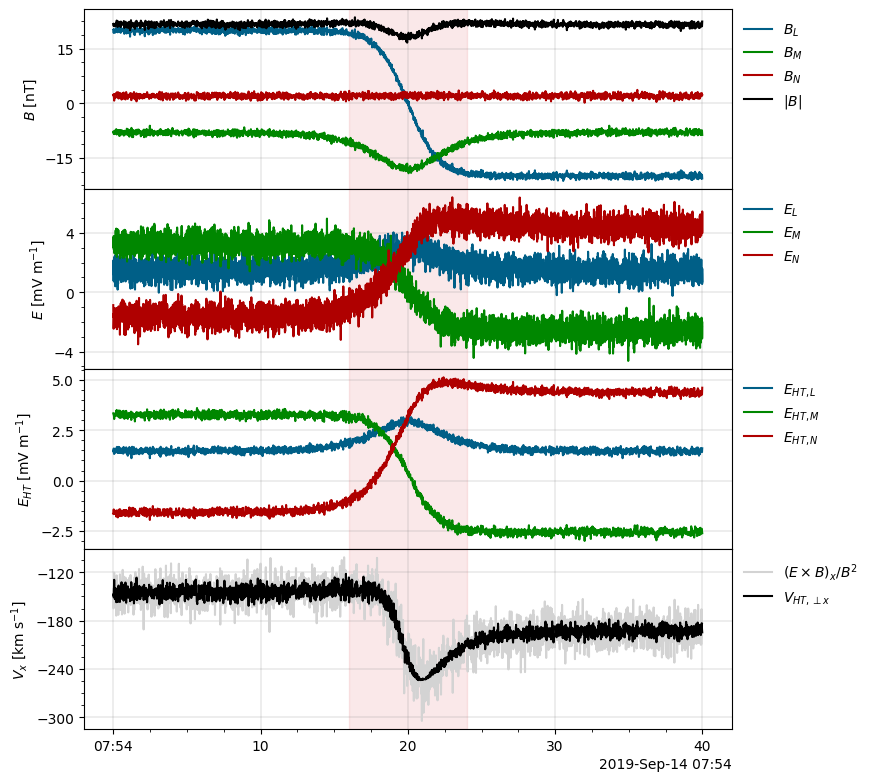

In [12]:
f, axs = plt.subplots(4, sharex="all", figsize=(9, 8))
f.subplots_adjust(hspace=0, left=0.1, right=0.82, top=0.97, bottom=0.07)
legend_opts = {"loc": "upper left", "bbox_to_anchor": (1.0, 1.0), "frameon": False}

plot_line(axs[0], b_lmn)
plot_line(axs[0], pyrf.norm(b_lmn), color="k")
axs[0].set_ylabel("$B$ [nT]")
axs[0].legend(["$B_L$", "$B_M$", "$B_N$", "$|B|$"], **legend_opts)

plot_line(axs[1], e_lmn)
axs[1].set_ylabel("$E$ [mV m$^{-1}$]")
axs[1].legend(["$E_L$", "$E_M$", "$E_N$"], **legend_opts)

plot_line(axs[2], pyrf.new_xyz(e_conv, lmn, "lmn"))
axs[2].set_ylabel("$E_{HT}$ [mV m$^{-1}$]")
axs[2].legend(["$E_{HT,L}$", "$E_{HT,M}$", "$E_{HT,N}$"], **legend_opts)

plot_line(axs[3], pyrf.resample(v_exb, v_ht_perp)[:, 0], color="lightgray")
plot_line(axs[3], v_ht_perp[:, 0], color="k")
axs[3].set_ylabel("$V_x$ [km s$^{-1}$]")
axs[3].legend([r"$(E\times B)_x / B^2$", r"$V_{HT,\bot x}$"], **legend_opts)

for ax in axs:
    ax.axvspan(*b_mva.time.data[[0, -1]], color="tab:red", alpha=0.1)

### Hodogram and HT scatter plot
The hodogram of the tangential field shows the rotation of the field across
the sheet. The scatter plot of $\mathbf{E}$ against $\mathbf{E}_{HT}$ shows
the quality of the HT frame.

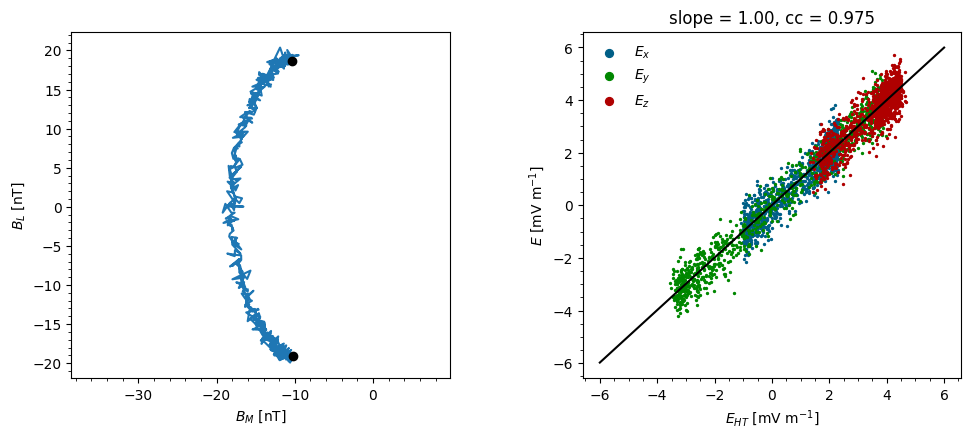

In [13]:
f, axs = plt.subplots(1, 2, figsize=(10, 4.5))
f.subplots_adjust(wspace=0.35, left=0.08, right=0.97, top=0.9, bottom=0.13)

b_lmn_mva = pyrf.time_clip(b_lmn, tint_mva)
axs[0].plot(b_lmn_mva[:, 1], b_lmn_mva[:, 0], color="tab:blue")
axs[0].plot(b_lmn_mva[[0, -1], 1], b_lmn_mva[[0, -1], 0], "ko")
axs[0].set_xlabel("$B_M$ [nT]")
axs[0].set_ylabel("$B_L$ [nT]")
axs[0].set_aspect("equal", adjustable="datalim")

for i, c in enumerate(["x", "y", "z"]):
    axs[1].scatter(e_ht.data[:, i], e_ht_obs.data[:, i], s=2, label=f"$E_{c}$")

e_lim = np.array([-6, 6])
axs[1].plot(e_lim, e_lim * slope + offset, color="k")
axs[1].set_xlabel("$E_{HT}$ [mV m$^{-1}$]")
axs[1].set_ylabel("$E$ [mV m$^{-1}$]")
axs[1].set_title(f"slope = {slope:.2f}, cc = {corr_coeff:.3f}")
axs[1].legend(frameon=False, markerscale=4)